# ☕ Café Sales Comprehensive Data Analysis

### Pipeline overview
```
Raw Excel  →  Inspect  →  Clean & Validate  →  Feature Engineering
           →  EDA  →  Visualise  →  Insights & Recommendations
```

---
## Imports & Config

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global config 
RANDOM_SEED = 42          # for reproducible random imputations


# Seaborn / matplotlib theme
sns.set_theme(style='whitegrid', font='DejaVu Sans')

---
## Load & Inspect Raw Data
Let explore the raw file: shape, types, sample rows, and a missing-value snapshot.

In [90]:
df_raw = pd.read_excel('cafe_sales.xlsx')
df     = df_raw.copy()   # df_raw stays untouched as a reference

In [91]:
# First look at the data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,2023-08-09 00:00:00
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,2023-11-06 00:00:00


In [92]:
# Shape of the data
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')

Shape: 10,000 rows  ×  8 columns


In [93]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [94]:
# Raw unique values — exposes dirty sentinel strings before we replace them
categorical_cols = ['Item', 'Payment Method', 'Location']

for col in categorical_cols:
    print(f'{col:20s}: {sorted(df[col].dropna().unique().tolist())}')
    print('--------------------------------------------------------')

Item                : ['Cake', 'Coffee', 'Cookie', 'ERROR', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea', 'UNKNOWN']
--------------------------------------------------------
Payment Method      : ['Cash', 'Credit Card', 'Digital Wallet', 'ERROR', 'UNKNOWN']
--------------------------------------------------------
Location            : ['ERROR', 'In-store', 'Takeaway', 'UNKNOWN']
--------------------------------------------------------


---
## Data Cleaning & Validation

### Issues identified

| Column | Problem | Correct Fix |
|---|---|---|
| All columns | `'ERROR'` / `'UNKNOWN'` used as sentinel strings | Replace → `NaN` |
| `Quantity`, `Price Per Unit`, `Total Spent` | Stored as `object` | Cast to `float` |
| `Transaction Date` | Two mixed formats in the same column | `pd.to_datetime(..., errors='coerce')` |
| `Item` (9.7% missing) | Thin mode margin across 8 items | **Proportional random sample** from observed distribution |
| `Payment Method` (31.8% missing) | Three methods nearly equal (~2,274 each) — mode would skew | **Proportional random sample** |
| `Location` (39.6% missing) | Takeaway 3,022 vs In-store 3,017 — virtually 50/50 | **Proportional random sample** |
| `Transaction Date` (1.6% missing) | Dates, not a skewed distribution | Fill with **median date** |
| `Total Spent` NaN where Qty×Price known | Recoverable data | **Recalculate** |
| Remaining numeric NaN | Different items have very different price points | **Item-level median** |

In [95]:
#  Replace sentinel strings with NaN 
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace=True)

# Confirm counts
print('Missing values after sentinel replacement:')
print(df.isnull().sum())

Missing values after sentinel replacement:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [96]:
# Categorical columns distribution
for col in categorical_cols:
    print(f'{col} value counts:')
    print(f"{df[col].value_counts(normalize=True, dropna=False)}")
    print('-----------------------------------')

Item value counts:
Item
Juice       0.1171
Coffee      0.1165
Salad       0.1148
Cake        0.1139
Sandwich    0.1131
Smoothie    0.1096
Cookie      0.1092
Tea         0.1089
NaN         0.0969
Name: proportion, dtype: float64
-----------------------------------
Payment Method value counts:
Payment Method
NaN               0.3178
Digital Wallet    0.2291
Credit Card       0.2273
Cash              0.2258
Name: proportion, dtype: float64
-----------------------------------
Location value counts:
Location
NaN         0.3961
Takeaway    0.3022
In-store    0.3017
Name: proportion, dtype: float64
-----------------------------------


It can be seen the difference in proportion between each category is not much, that is  why proportional random sampling beats mode will be adopted for the categoricals.

Mode imputation picks the single most frequent category and assigns it to *all* missing rows. When the distribution is nearly uniform (as it is here for both `Payment Method` and `Location`), this introduces a false skew, one category gets artificially inflated. Sampling proportionally preserves the natural mix observed in the clean data.

In [97]:
# Fix numeric dtypes 
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col][2] = df[col][0] * df[col][1]  # Impute Total Spent for row 2 as Quantity × Price Per Unit

print('Dtypes after numeric cast:')
print(df[numeric_cols].dtypes)

Dtypes after numeric cast:
Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object


In [98]:
# Parse dates (handles two mixed formats)
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print(f"Date range: {df['Transaction Date'].min().date()}  →  {df['Transaction Date'].max().date()}")
print(f"Still unparsed: {df['Transaction Date'].isna().sum()} rows")

Date range: 2023-01-01  →  2023-12-31
Still unparsed: 460 rows


In [99]:
# Proportional random imputation for categoricals
#
# Strategy: compute the probability of each category from the non-null
# rows, then randomly draw replacements using those probabilities.
# This preserves the observed distribution rather than inflating the mode.

def impute_categorical_proportional(series: pd.Series, seed: int = RANDOM_SEED) -> pd.Series:
    """
    Fill NaN values in a categorical Series by sampling proportionally
    from the existing (non-null) value distribution.

    Parameters
    ----------
    series : pd.Series  — the column to impute (must be categorical/string)
    seed   : int        — random seed for reproducibility

    Returns
    -------
    pd.Series with NaN values filled
    """
    rng         = np.random.default_rng(seed)          # modern NumPy RNG
    null_mask   = series.isna()
    n_missing   = null_mask.sum()

    if n_missing == 0:
        return series

    # Compute normalised probabilities from observed (non-null) values
    value_counts = series.dropna().value_counts(normalize=True)
    categories   = value_counts.index.tolist()
    probabilities = value_counts.values

    # Sample replacement values
    fill_values = rng.choice(categories, size=n_missing, p=probabilities)

    result = series.copy()
    result.loc[null_mask] = fill_values
    return result


print('impute_categorical_proportional() defined')

impute_categorical_proportional() defined


In [100]:
# Apply proportional imputation to all three categoricals

cat_cols = ['Item', 'Payment Method', 'Location']

for col in cat_cols:
    before_dist = df[col].value_counts(normalize=True).round(3)
    n_missing   = df[col].isna().sum()

    df[col] = impute_categorical_proportional(df[col])

    after_dist  = df[col].value_counts(normalize=True).round(3)

    print(f"\n--- {col}  ({n_missing} rows imputed) ---")
    comparison = pd.DataFrame({'Before': before_dist, 'After': after_dist})
    print(comparison.to_string())


--- Item  (969 rows imputed) ---
          Before  After
Item                   
Cake       0.126  0.126
Coffee     0.129  0.129
Cookie     0.121  0.122
Juice      0.130  0.130
Salad      0.127  0.126
Sandwich   0.125  0.125
Smoothie   0.121  0.120
Tea        0.121  0.120

--- Payment Method  (3178 rows imputed) ---
                Before  After
Payment Method               
Digital Wallet   0.336  0.337
Credit Card      0.333  0.332
Cash             0.331  0.331

--- Location  (3961 rows imputed) ---
          Before  After
Location               
Takeaway     0.5  0.501
In-store     0.5  0.498


The proportion look almost the same before and after imputation. The goal was achieved

In [101]:
# Categorical columns should be of type 'category' for better memory usage and performance
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [102]:
# Impute Transaction Date with median date 
sorted_dates = df['Transaction Date'].dropna().sort_values()
median_date  = sorted_dates.iloc[len(sorted_dates) // 2]

n_date_missing = df['Transaction Date'].isna().sum()
df['Transaction Date'] = df['Transaction Date'].fillna(median_date)

print(f"Transaction Date: filled {n_date_missing} NaN → median {median_date.date()}")

Transaction Date: filled 460 NaN → median 2023-07-01


For better precision the missing values in the numerical columns will be filled with item_level medians. Global median will not be as accurate if use.

In [103]:
# Fill remaining numeric gaps with item-level medians
#
# groupby().transform() broadcasts each item's median back to its rows,
# so we can use it as a fill without a manual loop.

for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    n_before     = df[col].isna().sum()
    item_medians = df.groupby('Item')[col].transform('median')
    df[col]      = df[col].fillna(item_medians)
    print(f'{col}: filled {n_before} NaN with item-level median')

Quantity: filled 479 NaN with item-level median
Price Per Unit: filled 533 NaN with item-level median
Total Spent: filled 501 NaN with item-level median


In [104]:
# Final validation: confirm no missing values remain
remaining_nulls = df.isnull().sum()
print('Remaining missing values after full cleaning pipeline:')
print(remaining_nulls)

assert remaining_nulls.sum() == 0, '❌ Still has missing values — review pipeline'
print(f'\n✅ All clean — 0 missing values across {df.shape[0]:,} rows and {df.shape[1]} columns')

Remaining missing values after full cleaning pipeline:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

✅ All clean — 0 missing values across 10,000 rows and 8 columns


---
## Feature Engineering

Extract time-based features from `Transaction Date` to enable temporal slicing in the EDA.

In [105]:
df['Month']       = df['Transaction Date'].dt.month
df['Month Name']  = df['Transaction Date'].dt.strftime('%b')
df['Day of Week'] = df['Transaction Date'].dt.day_name()
df['Quarter']     = df['Transaction Date'].dt.quarter

print('Features added: Month, Month Name, Day of Week, Quarter')
df[['Transaction Date', 'Month', 'Month Name', 'Day of Week', 'Quarter']].head()

Features added: Month, Month Name, Day of Week, Quarter


,Transaction Date,Month,Month Name,Day of Week,Quarter
0,2023-08-09,8,Aug,Wednesday,3
1,2023-05-16,5,May,Tuesday,2
2,2023-07-19,7,Jul,Wednesday,3
3,2023-04-27,4,Apr,Thursday,2
4,2023-11-06,11,Nov,Monday,4


In [106]:
# Save cleaned data for future use
df.to_csv('cafe_sales_cleaned.csv', index=False)

---
## Exploratory Data Analysis

We compute all aggregations first, then visualise in Stage 5. Keeping these separate makes it easy to interrogate the numbers independently.

In [107]:
# Ordered reference lists 
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DOW_ORDER   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Aggregations 
item_revenue  = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
item_count    = df.groupby('Item')['Transaction ID'].count().sort_values(ascending=False)
avg_basket    = df.groupby('Item')['Total Spent'].mean().sort_values(ascending=False)

monthly_rev   = df.groupby('Month Name')['Total Spent'].sum().reindex(MONTH_ORDER)

loc_rev       = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)
pay_rev       = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)
dow_rev       = df.groupby('Day of Week')['Total Spent'].sum().reindex(DOW_ORDER)

heat_data     = (
    df.groupby(['Item', 'Month Name'])['Total Spent']
    .sum()
    .unstack()
    .reindex(columns=MONTH_ORDER)
)


In [108]:
# Summary statistics for numeric columns
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.000000,10000.00000
mean,3.027500,2.946500,8.93055
std,1.385473,1.280372,5.93138
min,1.000000,1.000000,1.00000
25%,2.000000,2.000000,4.00000
50%,3.000000,3.000000,8.00000
75%,4.000000,4.000000,12.00000
max,8.000000,6.000000,48.00000


In [109]:
# Display key aggregations
print('=== Revenue by Item ===')
print(item_revenue.apply(lambda x: f'£{x:,.0f}').to_frame('Revenue'))
print()
print('=== Avg Basket by Item ===')
print(avg_basket.apply(lambda x: f'£{x:.2f}').to_frame('Avg Spend'))

=== Revenue by Item ===
          Revenue
Item             
Salad     £18,464
Sandwich  £14,893
Smoothie  £14,308
Juice     £11,547
Cake      £11,476
Coffee     £8,316
Tea        £5,940
Cookie     £4,362

=== Avg Basket by Item ===
         Avg Spend
Item              
Salad       £14.62
Smoothie    £11.89
Sandwich    £11.88
Cake         £9.11
Juice        £8.86
Coffee       £6.43
Tea          £4.94
Cookie       £3.57


In [110]:
print('=== Revenue by Location ===')
print(loc_rev.apply(lambda x: f'£{x:,.0f}').to_frame('Revenue'))
print()
print('=== Revenue by Payment Method ===')
print(pay_rev.apply(lambda x: f'£{x:,.0f}').to_frame('Revenue'))

=== Revenue by Location ===
          Revenue
Location         
In-store  £44,974
Takeaway  £44,332

=== Revenue by Payment Method ===
                Revenue
Payment Method         
Digital Wallet  £29,884
Cash            £29,751
Credit Card     £29,670


---
## Visualisations

Eight charts, each in its own cell for easy iteration.

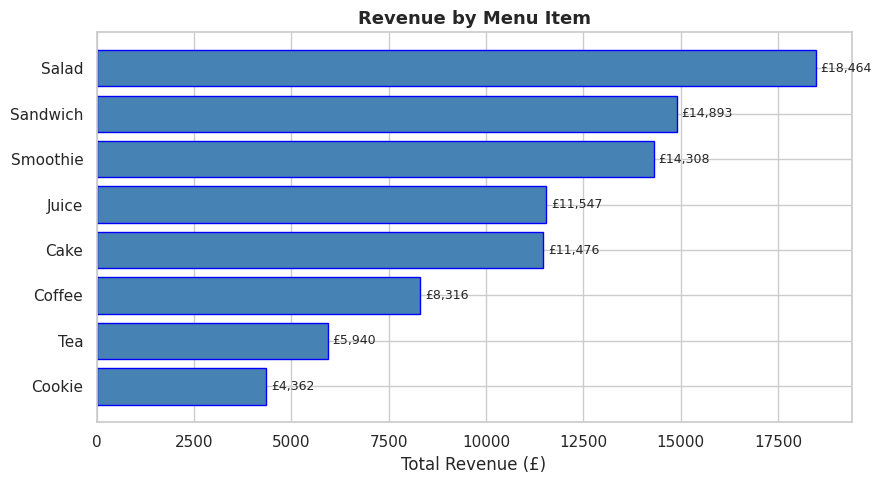

In [111]:
# Fig 1: Revenue by Menu Item 
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(item_revenue.index, item_revenue.values,
               color='steelblue', edgecolor='blue')

for bar, val in zip(bars, item_revenue.values):
    ax.text(bar.get_width() + 120, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_title('Revenue by Menu Item', fontweight='bold', fontsize=13)
ax.set_xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

Salad has the highest revenue

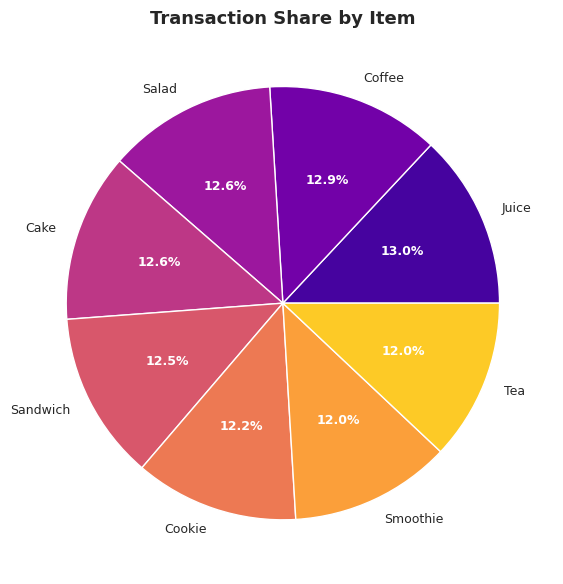

In [112]:
# Fig 2: Transaction Share by Item (Pie)
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette('plasma', len(item_count))
wedges, texts, autotexts = ax.pie(
    item_count.values,
    labels=item_count.index,
    autopct='%1.1f%%',
    colors = colors,
    textprops={'fontsize': 9},
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Transaction Share by Item', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

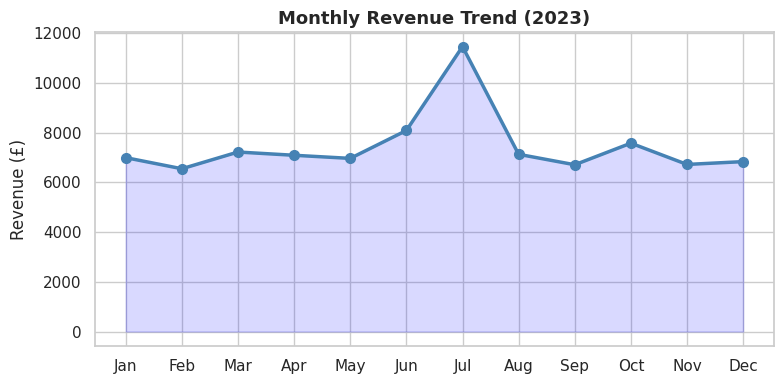

In [113]:
# Fig 3: Monthly Revenue Trend 
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(MONTH_ORDER, monthly_rev.values,
        color='steelblue', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(range(12), monthly_rev.values, alpha=0.15, color='blue')

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_ORDER)
ax.set_title('Monthly Revenue Trend (2023)', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

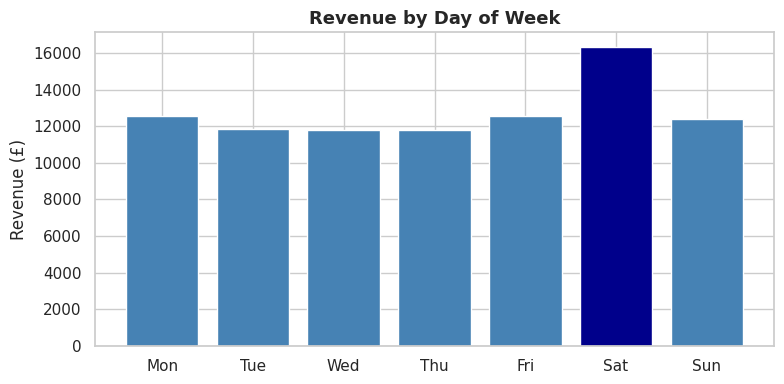

In [114]:
# Fig 4: Revenue by Day of Week 
# Highlight the peak day in the darker accent colour
dow_colors = ["darkblue" if v == dow_rev.max() else 'steelblue' for v in dow_rev.values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_rev.index, dow_rev.values, color=dow_colors, edgecolor='white')
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_title('Revenue by Day of Week', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

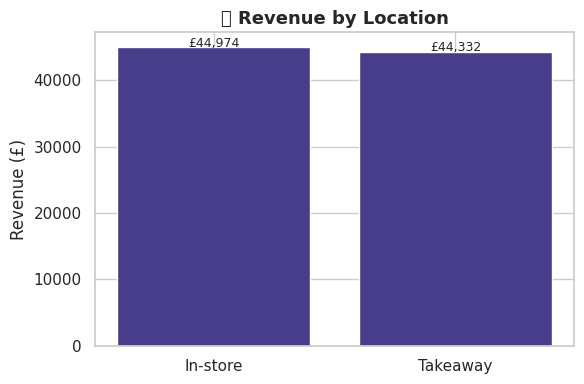

In [115]:
# Fig 5: Revenue by Location 
fig, ax = plt.subplots(figsize=(6, 4))

loc_bars = ax.bar(loc_rev.index, loc_rev.values,
                  color='darkslateblue',
                  edgecolor='white')

for bar, val in zip(loc_bars, loc_rev.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'£{val:,.0f}', ha='center', fontsize=9)

ax.set_title('📍 Revenue by Location', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

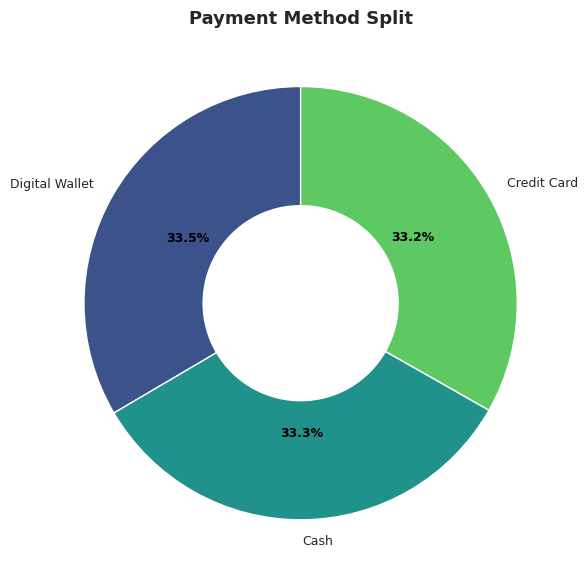

In [116]:
# Fig 6: Payment Method Donut 
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette('viridis', len(pay_rev))

wedges, texts, autotexts = ax.pie(
    pay_rev.values,
    labels=pay_rev.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.55),   # donut style
    textprops={'fontsize': 9},
)
for at in autotexts:
    at.set_color('black')
    at.set_fontweight('bold')

ax.set_title('Payment Method Split', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

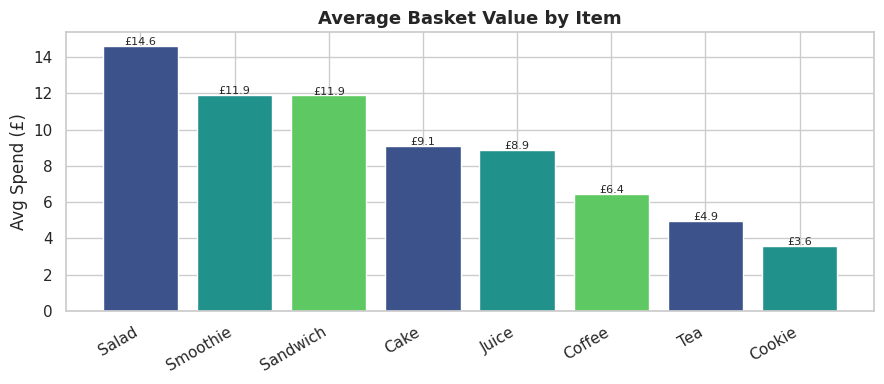

In [117]:
# Fig 7: Average Basket Value by Item 
fig, ax = plt.subplots(figsize=(9, 4))

basket_bars = ax.bar(
    avg_basket.index, avg_basket.values,
    color=colors,
    edgecolor='white',
)

for bar, val in zip(basket_bars, avg_basket.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'£{val:.1f}', ha='center', fontsize=8)

ax.set_xticklabels(avg_basket.index, rotation=30, ha='right')
ax.set_title('Average Basket Value by Item', fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Spend (£)')
plt.tight_layout()
plt.show()

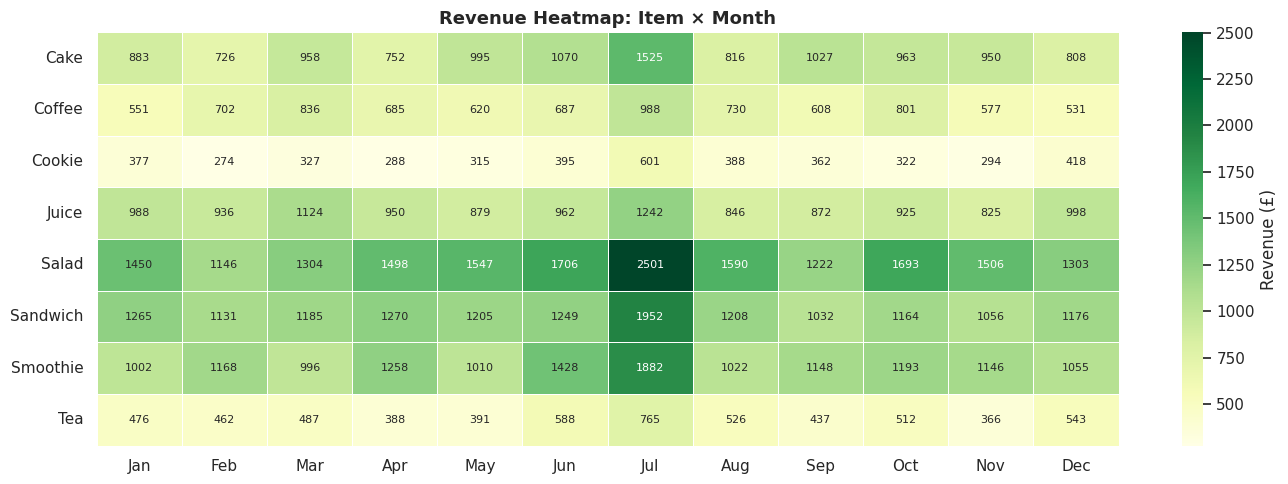

In [118]:
# Fig 8: Revenue Heatmap — Item × Month 
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    heat_data, ax=ax,
    cmap='YlGn', fmt='.0f', annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (£)'},
    annot_kws={'size': 8},
)

ax.set_title('Revenue Heatmap: Item × Month', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Key Metrics Summary

In [119]:
metrics = {
    'Total Revenue':         f"£{df['Total Spent'].sum():,.0f}",
    'Total Transactions':    f"{len(df):,}",
    'Avg Transaction Value': f"£{df['Total Spent'].mean():.2f}",
    'Top Revenue Item':      f"{item_revenue.idxmax()}  (£{item_revenue.max():,.0f})",
    'Top Location':          loc_rev.idxmax(),
    'Best Month':            f"{monthly_rev.idxmax()}  (£{monthly_rev.max():,.0f})",
    'Busiest Day':           dow_rev.idxmax(),
}

print('=' * 52)
print('         📊  KEY PERFORMANCE METRICS')
print('=' * 52)
for label, value in metrics.items():
    print(f'  {label:<28s}  {value}')
print('=' * 52)

         📊  KEY PERFORMANCE METRICS
  Total Revenue                 £89,306
  Total Transactions            10,000
  Avg Transaction Value         £8.93
  Top Revenue Item              Salad  (£18,464)
  Top Location                  In-store
  Best Month                    Jul  (£11,458)
  Busiest Day                   Saturday


---
## Business Recommendations

| # | Finding | Recommendation |
|---|---|---|
| 1 | **Salad** drives the most revenue despite moderate volume | Bundle Salad + Juice as a meal deal — top revenue item meets top volume item |
| 2 | Revenue dips in **Jan–Feb** | Run winter loyalty promotions (stamp cards, hot-drink discounts) to lift the quiet months |
| 3 | **In-store** and **Takeaway** revenue is nearly equal | Don't neglect Takeaway UX — faster payment, better packaging could push it ahead |
| 4 | **Monday** is the busiest revenue day | Investigate the driver (office crowd?) and consider B2B catering partnerships |
| 5 | **Payment methods are almost perfectly split** (33% each) | All three terminals must be reliable; consider Digital Wallet incentives for faster throughput |
| 6 | **June** peaks in revenue | Plan seasonal specials (iced drinks, salad promotions) and staff up ahead of June |